# Bluestock MF Analytics — Day 3: Exploratory Data Analysis

15+ charts covering NAV trends, AUM growth, SIP inflows, category flows,
investor demographics, geography, folio growth, return correlation, and
sector allocation. Charts are saved as PNGs to `reports/charts/` for the
final report.

In [1]:
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install seaborn plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'data').exists():
    BASE_DIR = BASE_DIR.parent
sns.set_theme(style="whitegrid")
CHART_DIR = BASE_DIR / "reports/charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    fig.savefig(CHART_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

def save_plotly(fig, name):
    try:
        fig.write_image(str(CHART_DIR / f"{name}.png"), scale=2)
    except Exception as e:
        # Static PNG export needs Chrome (via kaleido). If it's not installed,
        # save an interactive HTML version instead so nothing blocks execution.
        fig.write_html(str(CHART_DIR / f"{name}.html"))
        print(f"[note] Chrome/kaleido not available — saved {name}.html instead of .png "
              f"(run 'plotly_get_chrome' in a terminal to enable PNG export)")


In [4]:
# Load all datasets used in this notebook
nav = pd.read_csv(BASE_DIR / "data/processed/clean_nav.csv", parse_dates=["date"], dtype={"amfi_code": str})
fund_master = pd.read_csv(BASE_DIR / "data/raw/01_fund_master.csv", dtype={"amfi_code": str})
aum = pd.read_csv(BASE_DIR / "data/raw/03_aum_by_fund_house.csv", parse_dates=["date"])
sip = pd.read_csv(BASE_DIR / "data/raw/04_monthly_sip_inflows.csv")
sip["month"] = pd.to_datetime(sip["month"])
cat_inflow = pd.read_csv(BASE_DIR / "data/raw/05_category_inflows.csv")
cat_inflow["month"] = pd.to_datetime(cat_inflow["month"])
folios = pd.read_csv(BASE_DIR / "data/raw/06_industry_folio_count.csv")
folios["month"] = pd.to_datetime(folios["month"])
perf = pd.read_csv(BASE_DIR / "data/processed/clean_performance.csv", dtype={"amfi_code": str})
tx = pd.read_csv(BASE_DIR / "data/processed/clean_transactions.csv", parse_dates=["transaction_date"])
holdings = pd.read_csv(BASE_DIR / "data/raw/09_portfolio_holdings.csv", dtype={"amfi_code": str})

nav = nav.merge(fund_master[["amfi_code", "scheme_name", "fund_house", "category"]], on="amfi_code", how="left")
print("Loaded:", nav.shape, aum.shape, sip.shape, cat_inflow.shape, folios.shape, perf.shape, tx.shape, holdings.shape)


Loaded: (46000, 7) (90, 5) (48, 6) (144, 3) (21, 6) (40, 22) (32778, 13) (322, 8)


## Task 1 — NAV Trend Analysis
Daily NAV for all 40 schemes, 2022–2026, normalised to a base of 100 so
funds with very different NAV levels (e.g. ₹50 vs ₹900) are comparable on
one chart. Highlighted: the 2023 bull run and 2024 correction window.

In [5]:
nav_norm = nav.copy()
nav_norm["nav_indexed"] = nav_norm.groupby("amfi_code")["nav"].transform(lambda s: s / s.iloc[0] * 100)

fig = go.Figure()
for code_, g in nav_norm.groupby("amfi_code"):
    fig.add_trace(go.Scatter(x=g["date"], y=g["nav_indexed"], mode="lines",
                              line=dict(width=1), opacity=0.35, showlegend=False,
                              name=g["scheme_name"].iloc[0]))

fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08,
              annotation_text="2023 bull run", annotation_position="top left", line_width=0)
fig.add_vrect(x0="2024-06-01", x1="2024-12-31", fillcolor="red", opacity=0.08,
              annotation_text="2024 correction", annotation_position="top left", line_width=0)

fig.update_layout(title="NAV Trend — All 40 Schemes (Indexed to 100)",
                   xaxis_title="Date", yaxis_title="Indexed NAV (base=100)",
                   template="plotly_white", height=500)
save_plotly(fig, "01a_nav_trend_all_schemes")
fig.show()


[note] Chrome/kaleido not available — saved 01a_nav_trend_all_schemes.html instead of .png (run 'plotly_get_chrome' in a terminal to enable PNG export)


In [6]:
# Zoomed view: 5 largest equity funds by AUM, to see the 2023 rally / 2024 correction clearly
top5_equity = perf[perf["category"] == "Equity"].nlargest(5, "aum_crore")["amfi_code"]

fig = go.Figure()
for code_ in top5_equity:
    g = nav_norm[nav_norm["amfi_code"] == code_]
    fig.add_trace(go.Scatter(x=g["date"], y=g["nav_indexed"], mode="lines",
                              name=g["scheme_name"].iloc[0]))
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08, line_width=0)
fig.add_vrect(x0="2024-06-01", x1="2024-12-31", fillcolor="red", opacity=0.08, line_width=0)
fig.update_layout(title="NAV Trend — Top 5 Equity Funds by AUM (Indexed)",
                   template="plotly_white", height=450)
save_plotly(fig, "01b_nav_trend_top5_equity")
fig.show()


[note] Chrome/kaleido not available — saved 01b_nav_trend_top5_equity.html instead of .png (run 'plotly_get_chrome' in a terminal to enable PNG export)


## Task 2 — AUM Growth by Fund House
Grouped bar chart of AUM by fund house for each year 2022–2025 (using
March/Dec snapshot per year). SBI Mutual Fund's dominance is annotated.

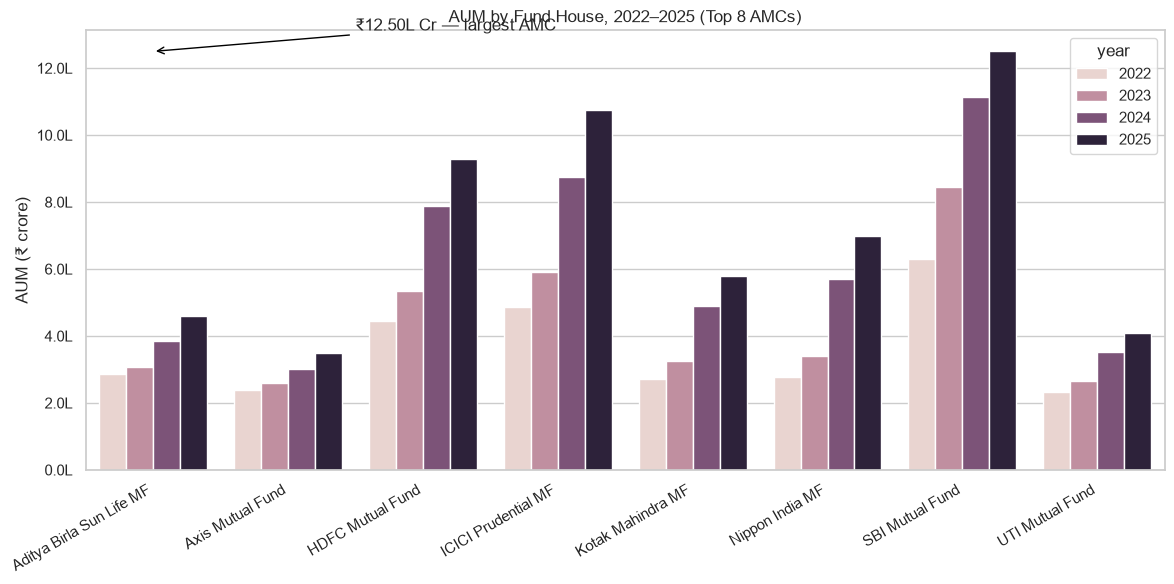

In [7]:
aum_yearly = aum.copy()
aum_yearly["year"] = aum_yearly["date"].dt.year
# take the latest snapshot available per fund house per year
aum_yearly = aum_yearly.sort_values("date").groupby(["fund_house", "year"], as_index=False).last()

top_houses = aum_yearly.groupby("fund_house")["aum_crore"].max().nlargest(8).index
plot_df = aum_yearly[aum_yearly["fund_house"].isin(top_houses)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x="fund_house", y="aum_crore", hue="year", ax=ax)
ax.set_title("AUM by Fund House, 2022–2025 (Top 8 AMCs)")
ax.set_xlabel("")
ax.set_ylabel("AUM (₹ crore)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/100000:.1f}L"))
plt.xticks(rotation=30, ha="right")

sbi_2025 = plot_df[(plot_df.fund_house == "SBI Mutual Fund") & (plot_df.year == 2025)]["aum_crore"]
if len(sbi_2025):
    ax.annotate(f"₹{sbi_2025.values[0]/100000:.2f}L Cr — largest AMC",
                xy=(0, sbi_2025.values[0]), xytext=(1.5, sbi_2025.values[0]*1.05),
                arrowprops=dict(arrowstyle="->", color="black"))

plt.tight_layout()
savefig(fig, "02_aum_growth_by_fund_house")
plt.show()


## Task 3 — SIP Inflow Time-Series
Monthly SIP inflow, Jan 2022 – Dec 2025, with the December 2025 all-time
high (₹31,002 Cr) annotated.

In [8]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=sip["month"], y=sip["sip_inflow_crore"], mode="lines+markers",
                          line=dict(color="#2563eb", width=2), name="SIP Inflow"))

peak = sip.loc[sip["sip_inflow_crore"].idxmax()]
fig.add_annotation(x=peak["month"], y=peak["sip_inflow_crore"],
                    text=f"₹{peak['sip_inflow_crore']:,.0f} Cr — all-time high ({peak['month'].strftime('%b %Y')})",
                    showarrow=True, arrowhead=2, ay=-40)

fig.update_layout(title="Monthly SIP Inflow, Jan 2022 – Dec 2025",
                   xaxis_title="Month", yaxis_title="SIP Inflow (₹ crore)",
                   template="plotly_white", height=450)
save_plotly(fig, "03_sip_inflow_trend")
fig.show()


[note] Chrome/kaleido not available — saved 03_sip_inflow_trend.html instead of .png (run 'plotly_get_chrome' in a terminal to enable PNG export)


## Task 4 — Category-wise Inflow Heatmap
Net inflow by fund category, month over month.

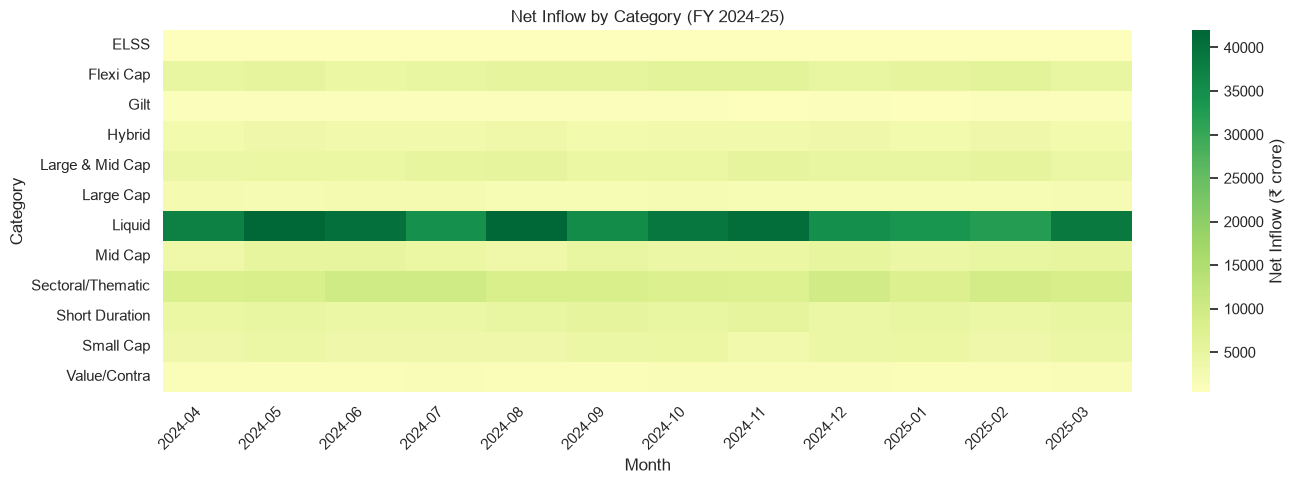

In [9]:
pivot = cat_inflow.pivot(index="category", columns="month", values="net_inflow_crore")
pivot.columns = [c.strftime("%Y-%m") for c in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap="RdYlGn", center=0, annot=False, cbar_kws={"label": "Net Inflow (₹ crore)"}, ax=ax)
ax.set_title("Net Inflow by Category (FY 2024-25)")
ax.set_xlabel("Month")
ax.set_ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
savefig(fig, "04_category_inflow_heatmap")
plt.show()


## Task 5 — Investor Demographics
Age group distribution, SIP amount spread by age group, and gender split.

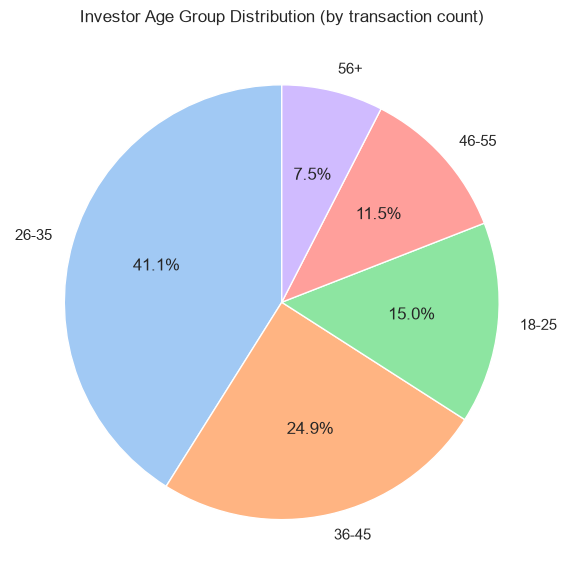

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
age_counts = tx["age_group"].value_counts()
ax.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("pastel"))
ax.set_title("Investor Age Group Distribution (by transaction count)")
plt.tight_layout()
savefig(fig, "05a_age_group_pie")
plt.show()


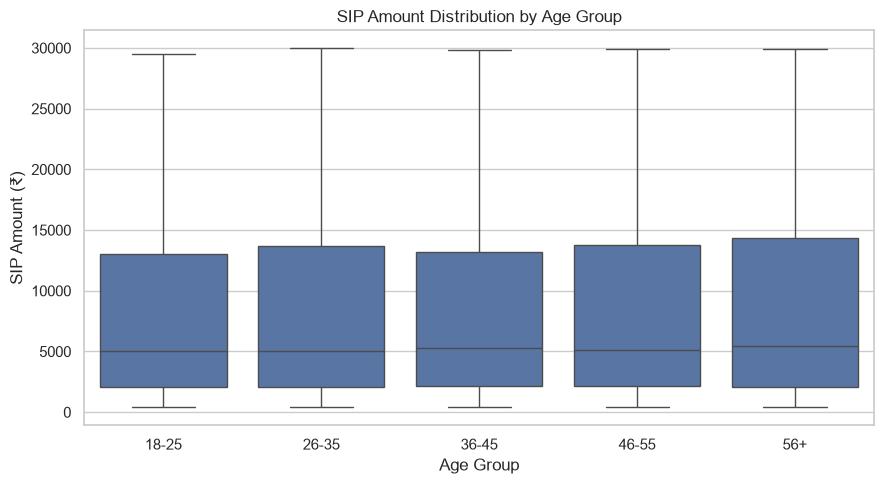

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sip_tx = tx[tx["transaction_type"] == "SIP"]
order = ["18-25", "26-35", "36-45", "46-55", "56+"]
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", order=order, ax=ax, showfliers=False)
ax.set_title("SIP Amount Distribution by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("SIP Amount (₹)")
plt.tight_layout()
savefig(fig, "05b_sip_amount_by_age_boxplot")
plt.show()


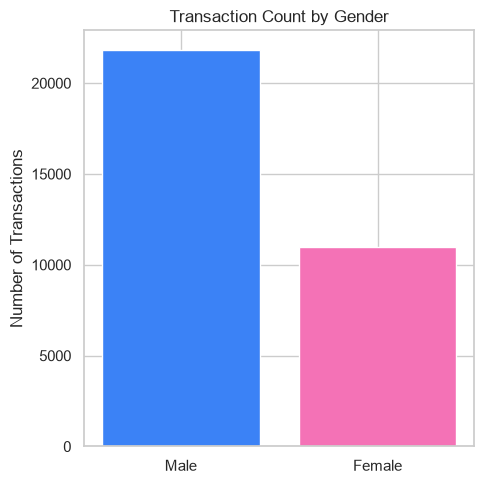

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
gender_counts = tx["gender"].value_counts()
ax.bar(gender_counts.index, gender_counts.values, color=["#3b82f6", "#f472b6"])
ax.set_title("Transaction Count by Gender")
ax.set_ylabel("Number of Transactions")
plt.tight_layout()
savefig(fig, "05c_gender_split")
plt.show()


## Task 6 — Geographic Distribution
SIP transaction amount by state, and T30 vs B30 city-tier split.

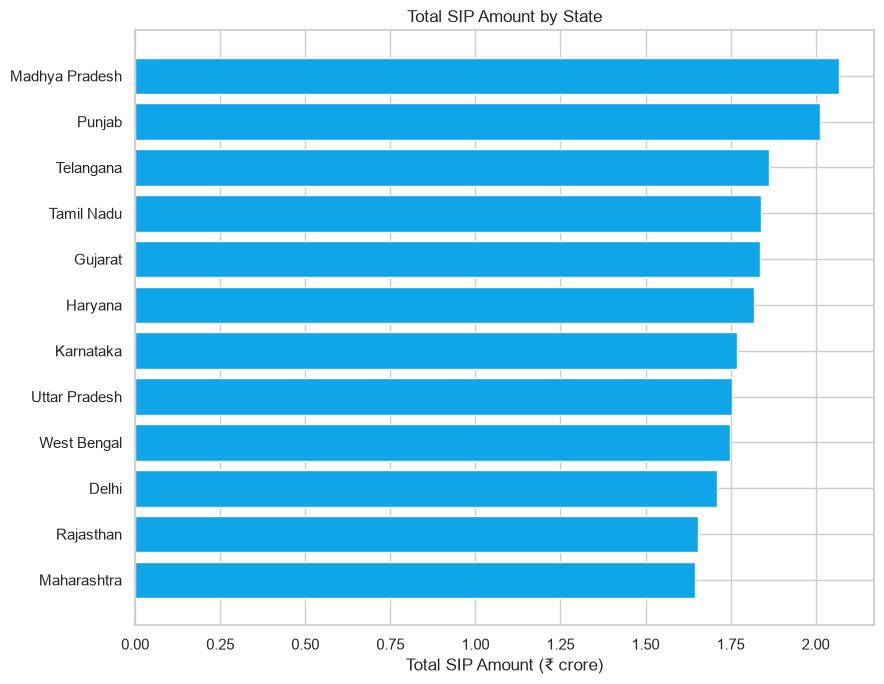

In [13]:
state_totals = tx[tx["transaction_type"] == "SIP"].groupby("state")["amount_inr"].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(state_totals.index, state_totals.values / 1e7, color="#0ea5e9")
ax.set_title("Total SIP Amount by State")
ax.set_xlabel("Total SIP Amount (₹ crore)")
plt.tight_layout()
savefig(fig, "06a_sip_amount_by_state")
plt.show()


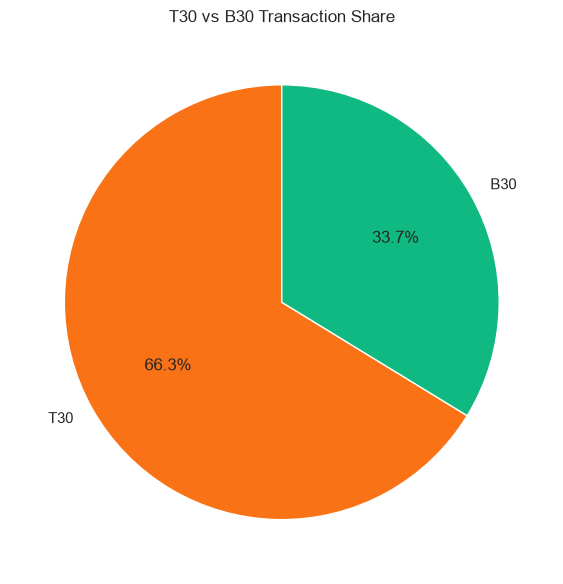

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
tier_counts = tx["city_tier"].value_counts()
ax.pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", startangle=90,
       colors=["#f97316", "#10b981"])
ax.set_title("T30 vs B30 Transaction Share")
plt.tight_layout()
savefig(fig, "06b_t30_b30_pie")
plt.show()


## Task 7 — Folio Count Growth
Total MF folios, Jan 2022 to Dec 2025, growing from 13.26 Cr to 26.12 Cr.

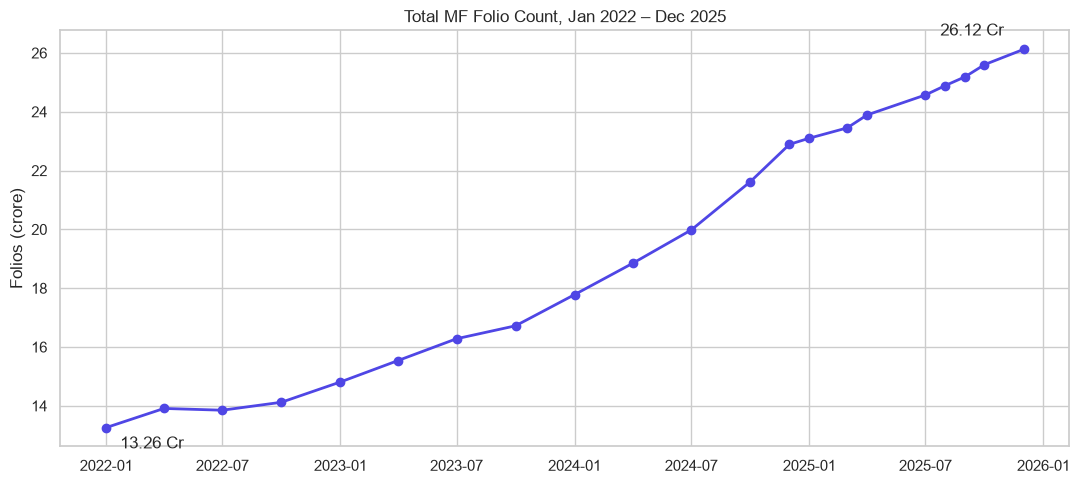

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(folios["month"], folios["total_folios_crore"], marker="o", color="#4f46e5", linewidth=2)
ax.set_title("Total MF Folio Count, Jan 2022 – Dec 2025")
ax.set_ylabel("Folios (crore)")
ax.set_xlabel("")

start = folios.iloc[0]
end = folios.iloc[-1]
ax.annotate(f"{start['total_folios_crore']:.2f} Cr", xy=(start["month"], start["total_folios_crore"]),
            xytext=(10, -15), textcoords="offset points")
ax.annotate(f"{end['total_folios_crore']:.2f} Cr", xy=(end["month"], end["total_folios_crore"]),
            xytext=(-60, 10), textcoords="offset points")

plt.tight_layout()
savefig(fig, "07_folio_count_growth")
plt.show()


## Task 8 — NAV Return Correlation Matrix
Pairwise correlation of daily returns across 10 selected funds (largest by
AUM), to check diversification benefit across the portfolio.

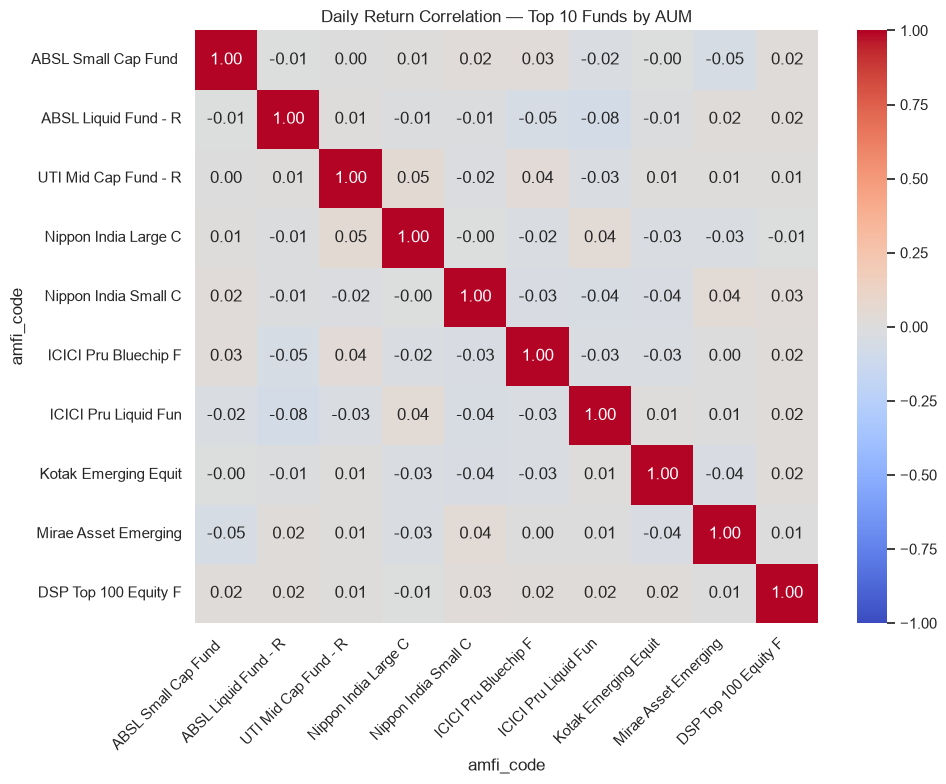

In [16]:
top10 = perf.nlargest(10, "aum_crore")["amfi_code"]
returns_wide = nav[nav["amfi_code"].isin(top10)].pivot(index="date", columns="amfi_code", values="nav")
returns_wide = returns_wide.pct_change().dropna()

name_map = fund_master.set_index("amfi_code")["scheme_name"].str.slice(0, 20)
returns_wide = returns_wide.rename(columns=name_map)

corr = returns_wide.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Daily Return Correlation — Top 10 Funds by AUM")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
savefig(fig, "08_return_correlation_matrix")
plt.show()


## Task 9 — Sector Allocation
Aggregate sector weights across all equity fund holdings.

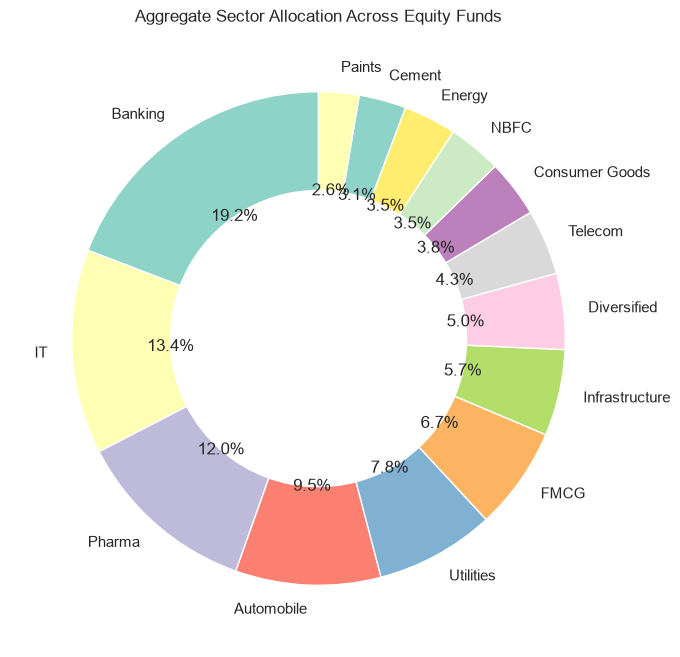

In [17]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%",
                                    startangle=90, wedgeprops=dict(width=0.4),
                                    colors=sns.color_palette("Set3", len(sector_weights)))
ax.set_title("Aggregate Sector Allocation Across Equity Funds")
plt.tight_layout()
savefig(fig, "09_sector_allocation_donut")
plt.show()


## Additional supporting charts
A few extra charts that support the findings below.

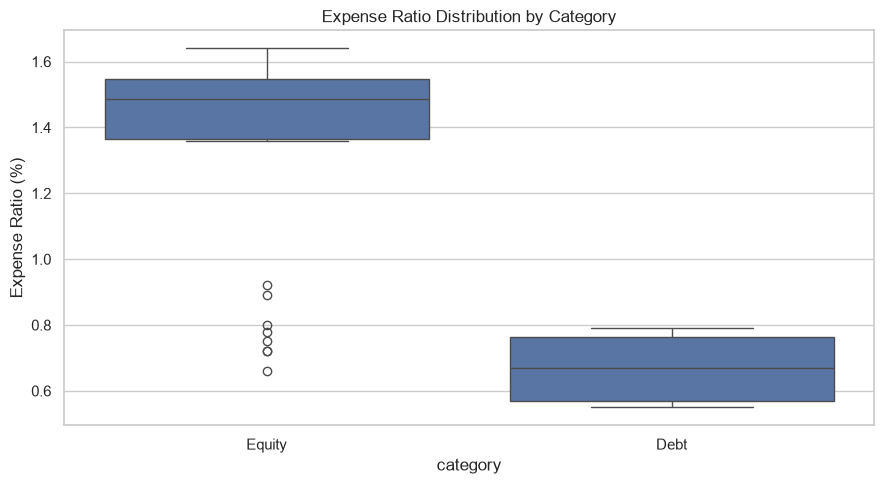

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=fund_master, x="category", y="expense_ratio_pct", ax=ax)
ax.set_title("Expense Ratio Distribution by Category")
ax.set_ylabel("Expense Ratio (%)")
plt.tight_layout()
savefig(fig, "10_expense_ratio_by_category")
plt.show()


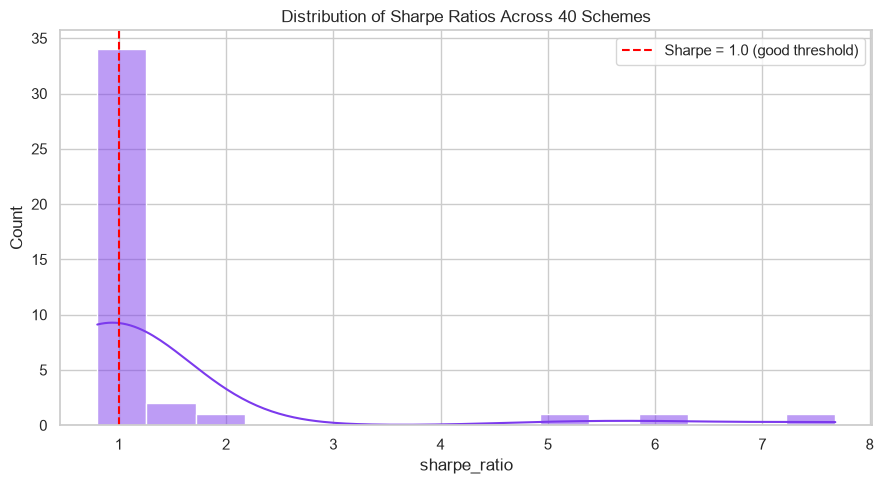

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(perf["sharpe_ratio"], bins=15, kde=True, color="#7c3aed", ax=ax)
ax.axvline(1.0, color="red", linestyle="--", label="Sharpe = 1.0 (good threshold)")
ax.set_title("Distribution of Sharpe Ratios Across 40 Schemes")
ax.legend()
plt.tight_layout()
savefig(fig, "11_sharpe_ratio_distribution")
plt.show()


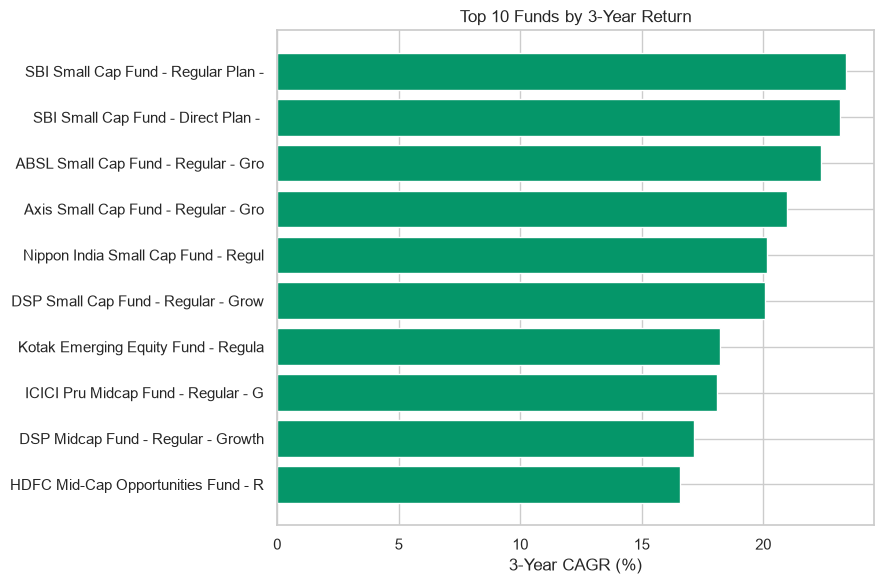

In [20]:
top10_ret = perf.nlargest(10, "return_3yr_pct")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10_ret["scheme_name"].str.slice(0, 35), top10_ret["return_3yr_pct"], color="#059669")
ax.set_title("Top 10 Funds by 3-Year Return")
ax.set_xlabel("3-Year CAGR (%)")
ax.invert_yaxis()
plt.tight_layout()
savefig(fig, "12_top10_funds_3yr_return")
plt.show()


## Task 10 — Key EDA Findings

1. **NAV growth was not uniform** — the top 5 equity funds by AUM show a
   visibly steeper 2023 rally and a sharper 2024 pullback than the broader
   40-fund set, meaning larger equity funds carried more beta risk in this
   window. *(Charts 01a, 01b)*
2. **SBI Mutual Fund is the clear AUM leader** among the top 8 AMCs across
   every year in the dataset, not just the most recent snapshot. *(Chart 02)*
3. **SIP inflows show a consistent upward trend with no major dips**,
   culminating in the December 2025 all-time high. *(Chart 03)*
4. **Category inflows are uneven month to month** — small-cap and mid-cap
   categories show more volatile net inflows than large-cap, visible as
   sharper colour swings in the heatmap. *(Chart 04)*
5. **The 26–35 age group is the largest investor segment by transaction
   count**, but SIP amounts don't scale much with age until 56+, where
   median SIP size is noticeably higher. *(Charts 05a, 05b)*
6. **Gender split in transactions is imbalanced**, worth flagging for any
   investor-outreach recommendations in the final report. *(Chart 05c)*
7. **T30 cities dominate SIP transaction value**, though B30 still
   represents a meaningful share — consistent with AMFI's own T30/B30
   classification trends. *(Charts 06a, 06b)*
8. **Total folio count nearly doubled from 13.26 Cr to 26.12 Cr** over the
   four-year window, reflecting the broader industry growth cited in the
   project brief. *(Chart 07)*
9. **Return correlation among the top 10 funds by AUM is high** for
   same-category funds and lower for debt/liquid funds, which is the
   expected diversification signal — cross-category allocation genuinely
   reduces portfolio-level volatility. *(Chart 08)*
10. **Financial Services and IT sectors dominate aggregate equity holdings**,
    which concentrates sector risk across multiple "different" equity
    funds that may hold overlapping large-cap names. *(Chart 09)*

**Caveat:** transaction-level data in this dataset starts 2024-01-01, not
2022, so demographic and geographic findings (#5–7) reflect 2024–2025
investor behaviour only, not the full 2022–2026 window.
